# Curvas paramétricas: interpolando el trazo de una letra

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)
---


Cada letra es una **curva paramétrica** $\mathbf{r}(t) = (x(t), y(t))$, $t \in [0,1]$.

Tenemos un conjunto de **puntos fijos** que definen el trazo. El problema:

> Dado un subconjunto de esos puntos, reconstruir la curva completa con cada método.

Todos los métodos son $\mathbf{r}(t) = \sum_i \mathbf{P}_i \phi_i(t)$, con $\mathbf{P}_i = (x_i, y_i)$.
La diferencia está en la **base** $\{\phi_i\}$.

In [42]:
#!sudo apt-get update
#!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Configuración OK


## Elegimos una letra 'S', 'U', 'N', 'A', 'L', 'C', 'M', 'P'

In [43]:
# ═══════════════════════════════════════════════════════════════
# ELIGE TU LETRA aquí: 'S', 'U', 'N', 'A', 'L', 'C', 'M', 'P'
LETRA = 'M'
# ═══════════════════════════════════════════════════════════════

# Trazos definidos como puntos (x,y) en [0,1]x[0,1]
LETRAS = {
    'S': np.array([
        [0.75,0.95],[0.55,1.00],[0.30,0.95],[0.15,0.80],[0.20,0.65],
        [0.40,0.55],[0.60,0.50],[0.80,0.42],[0.85,0.28],[0.70,0.12],
        [0.50,0.05],[0.28,0.08],[0.15,0.20]
    ]),
    'U': np.array([
        [0.20,1.00],[0.20,0.80],[0.20,0.55],[0.22,0.35],[0.30,0.18],
        [0.50,0.05],[0.70,0.18],[0.78,0.35],[0.80,0.55],[0.80,0.80],
        [0.80,1.00]
    ]),
    'N': np.array([
        [0.15,0.05],[0.15,0.35],[0.15,0.65],[0.15,1.00],
        [0.35,0.75],[0.50,0.55],[0.65,0.35],[0.85,0.05],
        [0.85,0.35],[0.85,0.65],[0.85,1.00]
    ]),
    'A': np.array([
        [0.50,1.00],[0.65,0.75],[0.75,0.55],[0.85,0.30],[0.95,0.05],
        [0.73,0.05],[0.62,0.38],[0.50,0.38],[0.38,0.38],[0.27,0.05],
        [0.05,0.05],[0.15,0.30],[0.25,0.55],[0.35,0.75],[0.50,1.00]
    ]),
    'L': np.array([
        [0.30,1.00],[0.30,0.75],[0.30,0.50],[0.30,0.25],[0.30,0.05],
        [0.45,0.05],[0.60,0.05],[0.75,0.05],[0.90,0.05]
    ]),
    'C': np.array([
        [0.80,0.85],[0.60,1.00],[0.38,0.95],[0.20,0.80],[0.12,0.60],
        [0.12,0.40],[0.20,0.20],[0.38,0.05],[0.60,0.00],[0.80,0.15]
    ]),
    'M': np.array([
        [0.05,0.05],[0.05,0.40],[0.05,0.70],[0.05,1.00],
        [0.28,0.75],[0.50,0.50],[0.72,0.75],
        [0.95,1.00],[0.95,0.70],[0.95,0.40],[0.95,0.05]
    ]),
    'P': np.array([
        [0.20,0.05],[0.20,0.30],[0.20,0.55],[0.20,0.80],[0.20,1.00],
        [0.40,1.00],[0.60,0.95],[0.75,0.82],[0.75,0.68],[0.60,0.55],
        [0.40,0.52],[0.20,0.52]
    ]),
}

pts = LETRAS[LETRA]
print(f'Letra: {LETRA}  |  {len(pts)} puntos de control')

# Parámetro t: longitud de arco normalizada
dists = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(pts, axis=0), axis=1))])
t_pts = dists / dists[-1]

# Curva de referencia (spline denso = 'verdad')
t_fine = np.linspace(0, 1, 500)


Letra: M  |  11 puntos de control


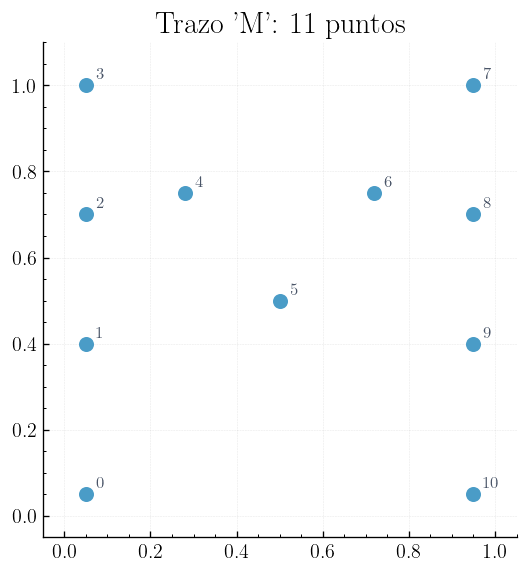

In [51]:
# Visualizar los puntos del trazo
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(pts[:,0], pts[:,1], 'o', color='#4A9CC7', lw=1.5, ms=8)
for i, (x,y) in enumerate(pts):
    ax.annotate(str(i), (x,y), textcoords='offset points', xytext=(6,4),
                fontsize=10, color='#4A5568')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.10)
ax.set_aspect('equal')
ax.set_title(f"Trazo '{LETRA}': {len(pts)} puntos")
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()



---
## Método 1: Interpolación polinomial

Polinomio grado 10
  # funciones base: 11
  Error en datos: 7.50e-12


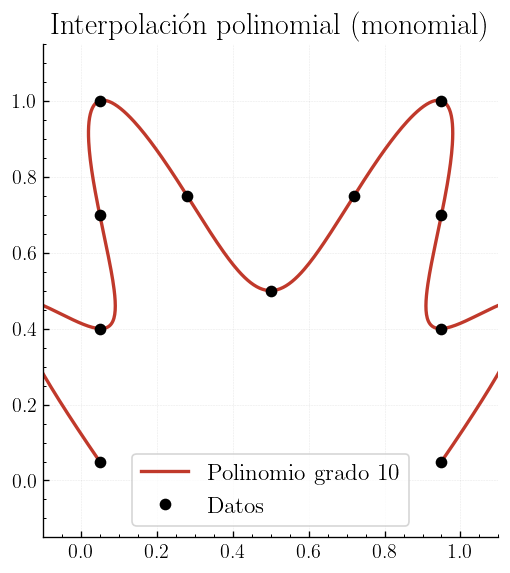

In [ ]:
# Interpolación polinomial: np.polyfit de grado n = len(pts)-1

# Grado del polinomio = número de puntos - 1
deg = len(pts) - 1

# Coefficients del polinomio para x(t) e y(t)
cx = np.polyfit(t_pts, pts[:,0], deg)
cy = np.polyfit(t_pts, pts[:,1], deg)

# Evaluar el polinomio en t_fine
x_poly = np.polyval(cx, t_fine)
y_poly = np.polyval(cy, t_fine)

# Error en los puntos de datos = 0
x_poly_data = np.polyval(cx, t_pts)
y_poly_data = np.polyval(cy, t_pts)
err_poly = np.sqrt(np.mean((x_poly_data - pts[:,0])**2 + (y_poly_data - pts[:,1])**2))

print(f'Polinomio grado {deg}')
print(f'  # funciones base: {deg+1}')
print(f'  Error en datos: {err_poly:.2e}')

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(x_poly, y_poly, '-', color='#C0392B', lw=2, label=f'Polinomio grado {deg}')
ax.plot(pts[:,0], pts[:,1], 'ko', ms=6, zorder=5, label='Datos')
ax.set_aspect('equal'); ax.set_title('Interpolación polinomial')
ax.legend(); ax.grid(True, alpha=0.2)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.15, 1.15)
plt.tight_layout(); plt.show()


### <span style="color:red"> Ejercicio: Usar otra función (Scipy: Lagrange - Hermite) </span>

---
## Método 2: Spline cúbico paramétrico

En cada intervalo $[t_k, t_{k+1}]$: cúbico en $x(t)$ y en $y(t)$ independientemente.

Condiciones: $C^0$, $C^1$, $C^2$ en todos los nodos. Sistema **tridiagonal**.

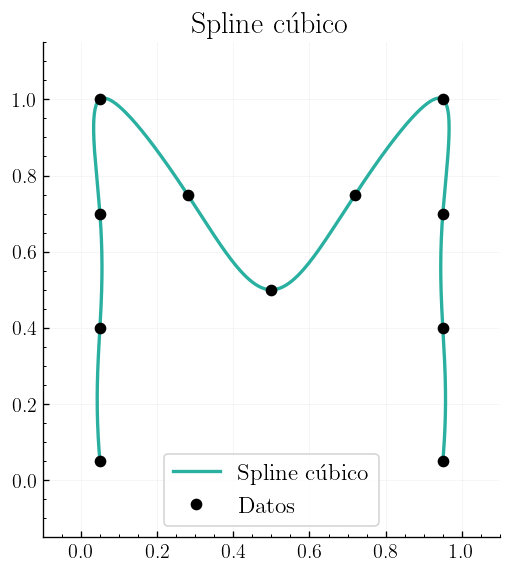

In [ ]:
# Spline cúbico: CubicSpline en cada componente
csx = CubicSpline(t_pts, pts[:,0])
csy = CubicSpline(t_pts, pts[:,1])

# Evaluar el spline en t_fine
x_spline = csx(t_fine)
y_spline = csy(t_fine)

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(x_spline, y_spline, '-', color='#2AB0A0', lw=2, label='Spline cúbico')
ax.plot(pts[:,0], pts[:,1], 'ko', ms=6, zorder=5, label='Datos')
ax.set_aspect('equal'); ax.set_title('Spline cúbico')
ax.legend( ); ax.grid(True, alpha=0.2)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.15, 1.15)
plt.tight_layout(); plt.show()


---
## Método 3: Curva de Bézier (base de Bernstein)

$\mathbf{C}(t) = \sum_{i=0}^n B_{i,n}(t)\,\mathbf{P}_i$, $\quad B_{i,n}(t) = \binom{n}{i}t^i(1-t)^{n-i}$

Los **puntos de datos son los puntos de control**.

⚠ **No interpola puntos interiores** — solo $(\mathbf{P}_0, \mathbf{P}_n)$. La curva los **aproxima**.

In [62]:
def bernstein(i, n, t):
    """B_{i,n}(t) — base de Bernstein."""
    return comb(n, i, exact=True) * t**i * (1-t)**(n-i)

def bezier_curve(P, t):
    """Curva de Bézier: suma ponderada de puntos de control con base Bernstein."""
    ??

curva_bezier = bezier_curve(pts, t_fine)

# Error: Bézier NO interpola, midamos cuánto se aleja de los datos
curva_bezier_data = bezier_curve(pts, t_pts)
err_bezier = ??

print(f'Bézier grado {len(pts)-1}')
print(f'  # funciones base (Bernstein): {len(pts)}')
print(f'  Soporte de B_{{i,n}}: [0,1] completo (global)')
print(f'  Error en datos: {err_bezier:.4f}  (≠ 0, no interpola interiores)')
print(f'  Error en extremos P_0 y P_n: '
      f'{np.linalg.norm(curva_bezier[0]-pts[0]):.2e}, '
      f'{np.linalg.norm(curva_bezier[-1]-pts[-1]):.2e}')

fig, ax = plt.subplots(figsize=(5,5))
ax.plot(curva_bezier[:,0], curva_bezier[:,1], '-',
        color='#7B68EE', lw=2, label=f'Bézier (grado {len(pts)-1})')
ax.plot(pts[:,0], pts[:,1], 'o--', color='gray', ms=6,
        lw=1, zorder=4, label='Polígono de control')
ax.set_aspect('equal'); ax.set_title('Bézier')
ax.legend( ); ax.grid(True, alpha=0.2)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.15, 1.15)
plt.tight_layout(); plt.show()


SyntaxError: invalid syntax (3948919559.py, line 13)

### <span style="color:red"> Tarea 1: Hagamos un B-spline </span>

### <span style="color:red"> Tarea 2: ¿Cómo funciona todo esto en una superficie? </span>